# Order Delay Intelligence Project

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [ ]:
orders = pd.read_csv("Dataset/olist_orders_dataset.csv")

payments = pd.read_csv("Dataset/olist_order_payments_dataset.csv")

customers = pd.read_csv("Dataset/olist_customers_dataset.csv")

items = pd.read_csv("Dataset/olist_order_items_dataset.csv")

products = pd.read_csv("Dataset/olist_products_dataset.csv")
print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [5]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Items:", items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Payments: (103886, 5)
Products: (32951, 9)


In [6]:
print("Orders Dataset")
orders.info()

print("\nCustomers Dataset")
customers.info()

print("\nItems Dataset")
items.info()

Orders Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Customers Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   custome

In [7]:
print("Orders Missing Values")
print(orders.isnull().sum())

print("\nCustomers Missing Values")
print(customers.isnull().sum())

print("\nItems Missing Values")
print(items.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())

Orders Missing Values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Customers Missing Values
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Items Missing Values
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products Missing Values
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2

In [8]:
print("Orders Duplicates:", orders.duplicated().sum())

print("Customers Duplicates:", customers.duplicated().sum())

print("Items Duplicates:", items.duplicated().sum())

print("Products Duplicates:", products.duplicated().sum())

Orders Duplicates: 0
Customers Duplicates: 0
Items Duplicates: 0
Products Duplicates: 0


# Dataset Audit Summary

The datasets were successfully loaded and inspected to understand their structure and quality before analysis.

The audit process included:

- Checking dataset dimensions and record counts
- Reviewing column names and data types
- Identifying missing values
- Detecting duplicate records

### Key Findings

- The Orders dataset contains 99,441 records.
- Customer information is complete with no missing values.
- Some delivery-related date columns contain missing values, which is expected for orders that were cancelled or not yet delivered.
- Product-related datasets contain a very small number of missing values.
- No significant duplicate records were found in the primary datasets.

The audit confirms that the datasets are suitable for further cleaning, feature engineering, exploratory data analysis, and machine learning tasks.

In [9]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

print("Date conversion completed")

Date conversion completed


In [10]:
orders[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
].dtypes

order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object

In [11]:
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

orders[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_time_days"
    ]
].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


In [12]:
orders["is_delayed"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
).astype(int)

orders["is_delayed"].value_counts()

is_delayed
0    91614
1     7827
Name: count, dtype: int64

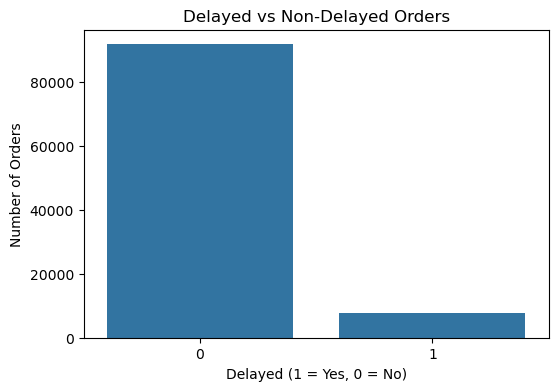

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="is_delayed",
    data=orders
)

plt.title("Delayed vs Non-Delayed Orders")
plt.xlabel("Delayed (1 = Yes, 0 = No)")
plt.ylabel("Number of Orders")

plt.show()

### Insight 1

The majority of orders were delivered on time, while only a small percentage experienced delays.

From the analysis, approximately 91,614 orders were delivered within the estimated delivery period, whereas around 7,827 orders were delayed.

This indicates that the logistics and delivery process performs reliably for most customers. However, delayed orders still represent an important business challenge because they can negatively affect customer satisfaction and overall shopping experience.

Understanding the factors that contribute to delayed deliveries can help improve operational efficiency and support the development of predictive models for delivery delay detection.

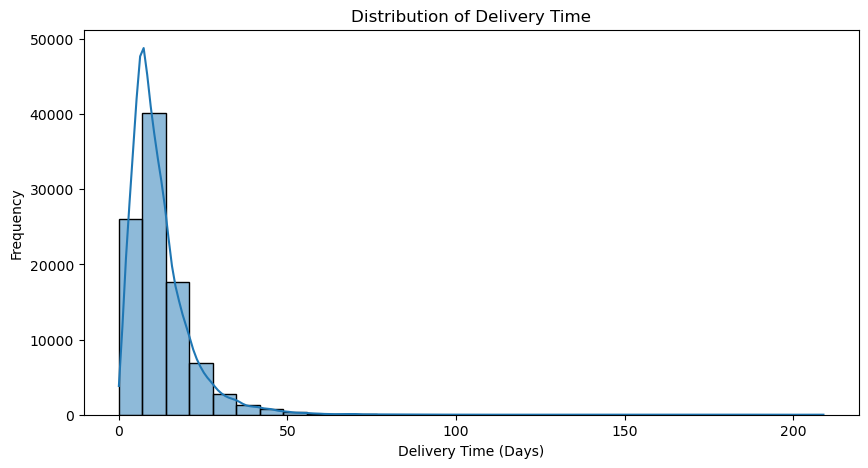

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders["delivery_time_days"],
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Frequency")

plt.show()

### Insight 2

Most deliveries are completed within a relatively small number of days, while a smaller group of orders takes significantly longer.

This suggests that most deliveries follow a predictable timeline, but some orders experience unusually long delays.

In [16]:
orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.month
)

orders["purchase_month"].head()

0    10
1     7
2     8
3    11
4     2
Name: purchase_month, dtype: int32

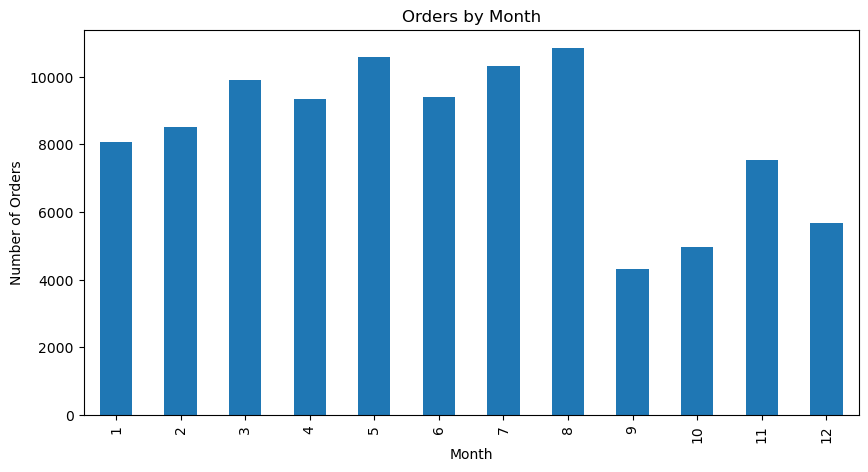

In [17]:
monthly_orders = (
    orders.groupby("purchase_month")
    .size()
)

plt.figure(figsize=(10,5))

monthly_orders.plot(
    kind="bar"
)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

### Insight 3

Order volume varies across different months of the year, indicating seasonal purchasing behavior.

Certain months experience higher transaction volumes than others, which may be influenced by holidays, promotional campaigns, or customer shopping patterns.

Understanding monthly demand trends can help businesses improve inventory planning, staffing decisions, and logistics management.

In [18]:
orders["purchase_weekday"] = (
    orders["order_purchase_timestamp"]
    .dt.day_name()
)

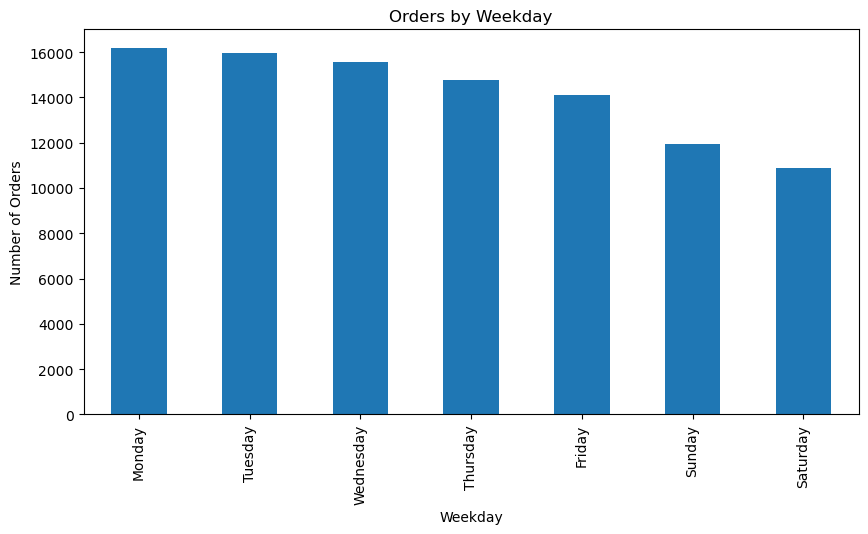

In [19]:
weekday_orders = (
    orders["purchase_weekday"]
    .value_counts()
)

plt.figure(figsize=(10,5))

weekday_orders.plot(
    kind="bar"
)

plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")

plt.show()

### Insight 4

Customer purchasing activity differs across weekdays.

Some days attract significantly more orders than others, suggesting that customer shopping behavior follows weekly patterns.

These insights can help businesses schedule marketing campaigns and optimize operational resources during peak shopping days.

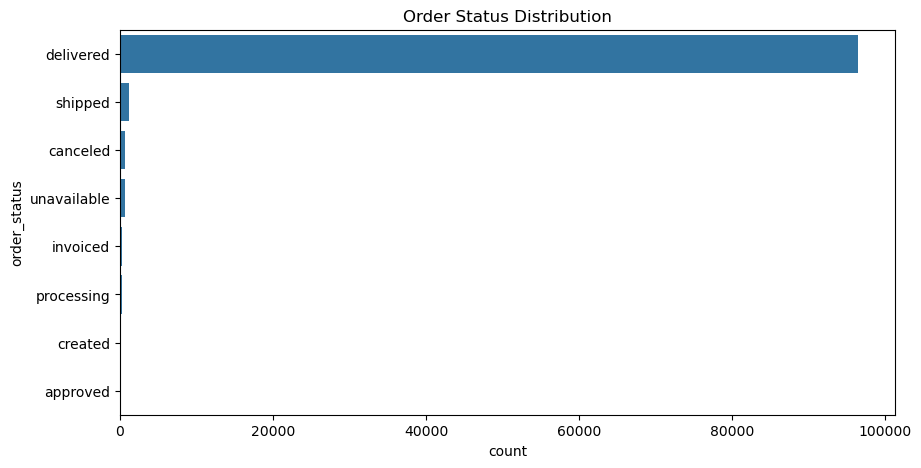

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="order_status",
    data=orders,
    order=orders["order_status"].value_counts().index
)

plt.title("Order Status Distribution")

plt.show()

### Insight 5

Most orders successfully reach the delivered status, while cancelled, unavailable, and processing orders represent a relatively small portion of total transactions.

This indicates that the order fulfillment process is generally effective, although improving the handling of non-delivered orders could further enhance customer satisfaction.

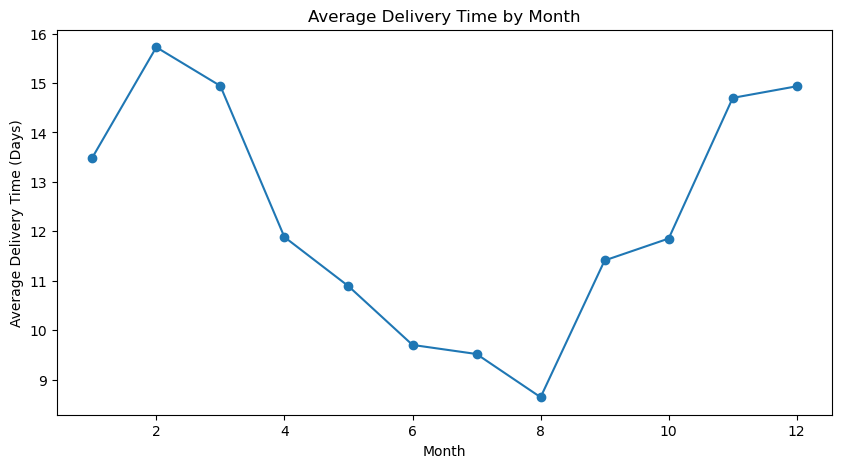

In [21]:
monthly_delivery = (
    orders.groupby("purchase_month")[
        "delivery_time_days"
    ]
    .mean()
)

plt.figure(figsize=(10,5))

monthly_delivery.plot(
    marker="o"
)

plt.title("Average Delivery Time by Month")
plt.xlabel("Month")
plt.ylabel("Average Delivery Time (Days)")

plt.show()

### Insight 6

Average delivery time changes across different months, suggesting that seasonal factors may influence logistics performance.

Periods with longer delivery times may be associated with higher order volumes, transportation constraints, or operational challenges.

Monitoring these trends can help improve delivery planning and customer experience.

# Business Insights Summary

The exploratory data analysis revealed several important business findings:

1. Most orders are delivered on time, while delayed deliveries account for a smaller proportion of transactions.

2. Delivery times are concentrated within a predictable range, although some orders experience unusually long delays.

3. Order volume changes throughout the year, indicating seasonal purchasing patterns.

4. Customer purchasing behavior varies across weekdays.

5. The majority of orders successfully reach the delivered status.

6. Average delivery times fluctuate across months, suggesting seasonal effects on logistics performance.

These insights provide valuable information for understanding customer behavior, delivery efficiency, and factors that may contribute to delayed deliveries.

# SQLite Database Analysis

In [22]:
import sqlite3

In [23]:
conn = sqlite3.connect("order_delay.db")

print("Database Created Successfully")

Database Created Successfully


In [24]:
orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

items.to_sql(
    "items",
    conn,
    if_exists="replace",
    index=False
)

payments.to_sql(
    "payments",
    conn,
    if_exists="replace",
    index=False
)

products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

print("Tables Created Successfully")

Tables Created Successfully


In [25]:
query = """
SELECT COUNT(*) AS total_orders
FROM orders
"""

pd.read_sql(query, conn)

,total_orders
0,99441


### SQL Insight 1

The dataset contains nearly one hundred thousand customer orders, providing a strong foundation for delivery and customer behavior analysis.

In [26]:
query = """
SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC
"""

pd.read_sql(query, conn)

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


### SQL Insight 2

Most orders are successfully delivered, while cancelled and unavailable orders represent only a small percentage of transactions.

In [27]:
query = """
SELECT
AVG(delivery_time_days) AS avg_delivery_days
FROM orders
"""

pd.read_sql(query, conn)

,avg_delivery_days
0,12.094086


### SQL Insight 3

The average delivery time provides an overall measure of logistics performance and customer service efficiency.

In [28]:
query = """
SELECT
SUM(is_delayed) AS delayed_orders
FROM orders
"""

pd.read_sql(query, conn)

,delayed_orders
0,7827


### SQL Insight 4

Although most deliveries arrive on time, a noticeable number of orders experience delays, highlighting opportunities for process improvement.

In [29]:
query = """
SELECT
    is_delayed,
    COUNT(*) AS total_orders
FROM orders
GROUP BY is_delayed
"""
pd.read_sql(query, conn)

,is_delayed,total_orders
0,0,91614
1,1,7827


### SQL Insight 5

Most orders are delivered on time, while delayed orders represent a smaller portion of total transactions.

In [30]:
query = """
SELECT
    purchase_month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY purchase_month
ORDER BY purchase_month
"""
pd.read_sql(query, conn)

,purchase_month,total_orders
0,1,8069
1,2,8508
2,3,9893
3,4,9343
4,5,10573
5,6,9412
6,7,10318
7,8,10843
8,9,4305
9,10,4959


### SQL Insight 6

Order volume varies throughout the year, confirming seasonal purchasing behavior observed during EDA.

In [31]:
query = """
SELECT
    c.customer_state,
    COUNT(*) AS total_orders
FROM orders o
JOIN customers c
ON o.customer_id = c.customer_id
GROUP BY c.customer_state
ORDER BY total_orders DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,customer_state,total_orders
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


### SQL Insight 7

Certain states contribute significantly more orders than others, indicating regional concentration of demand.

In [33]:
query = """
SELECT
    payment_type,
    COUNT(*) AS transactions
FROM payments
GROUP BY payment_type
ORDER BY transactions DESC
"""
pd.read_sql(query, conn)

,payment_type,transactions
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


### SQL Insight 8

Customers show clear preferences for specific payment methods, which can influence checkout optimization strategies.

In [34]:
query = """
SELECT
    payment_type,
    ROUND(AVG(payment_value),2) AS avg_payment
FROM payments
GROUP BY payment_type
ORDER BY avg_payment DESC
"""
pd.read_sql(query, conn)

,payment_type,avg_payment
0,credit_card,163.32
1,boleto,145.03
2,debit_card,142.57
3,voucher,65.70
4,not_defined,0.00


### SQL Insight 9

Different payment methods are associated with different average transaction values.

In [35]:
query = """
SELECT
    order_id,
    payment_value
FROM payments
WHERE payment_value >
(
    SELECT AVG(payment_value)
    FROM payments
)
LIMIT 20
"""
pd.read_sql(query, conn)

,order_id,payment_value
0,1f78449c87a54faf9e96e88ba1491fa9,341.09
1,d88e0d5fa41661ce03cf6cf336527646,188.73
2,12e5cfe0e4716b59afb0e0f4a3bd6570,157.45
3,8ac09207f415d55acff302df7d6a895c,244.15
4,4214cda550ece8ee66441f459dc33a8c,170.57
5,4d680edbaa7d3d9bed69532957368a03,353.09
6,8cd68144cdb62dc0d60848cf8616d2a4,330.66
7,d0a945f85ba1074b60aac97ade7e240e,541.00
8,5d9c5817e278892b7498d90bfa28ade8,290.16
9,b69b9260e79a0da00e15f48de1bd2524,283.34


### SQL Insight 10

The subquery identifies orders with payment values above the overall average transaction amount, helping highlight higher-value purchases.

# SQL vs Pandas Comparison

The monthly order volume analysis was performed using both Pandas and SQL.

Both approaches produced consistent results, confirming the accuracy of the data processing workflow.

Pandas provides flexibility for data manipulation and visualization, while SQL offers efficient querying and aggregation directly within the database.

Using both tools together creates a powerful analytics workflow for business intelligence and machine learning projects.

# Classification Model - Predicting Delayed Orders